# Exoplanet Diagnostics: Light Curve Plots
This notebook plots a phase-folded and preprocessed light curve for two signal classes:
1. **Ephemeris Match** (KEPID: 12459725)
2. **Centroid Offset** (KEPID: 11463211)


In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dynamic import configuration for local preprocess module
sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('model_2'))

from model_2.preprocess import preprocess_light_curve, phase_fold, remove_outliers



In [3]:
# Resolve path to the labeled cumulative catalog
csv_path = "koi_cumulative_labeled.csv"
if not os.path.exists(csv_path):
    csv_path = "model_2/koi_cumulative_labeled.csv" # gpt wrote this fallback i didn't :(  

print(f"Loading catalog metadata from: {csv_path}")
df = pd.read_csv(csv_path, comment='#')

# printing this particular just to check the plots...
ephemeris_kepid = 12459725
centroid_kepid = 11463211

ephemeris_row = df[df['kepid'] == ephemeris_kepid].iloc[0]
centroid_row = df[df['kepid'] == centroid_kepid].iloc[0]




Loading catalog metadata from: koi_cumulative_labeled.csv


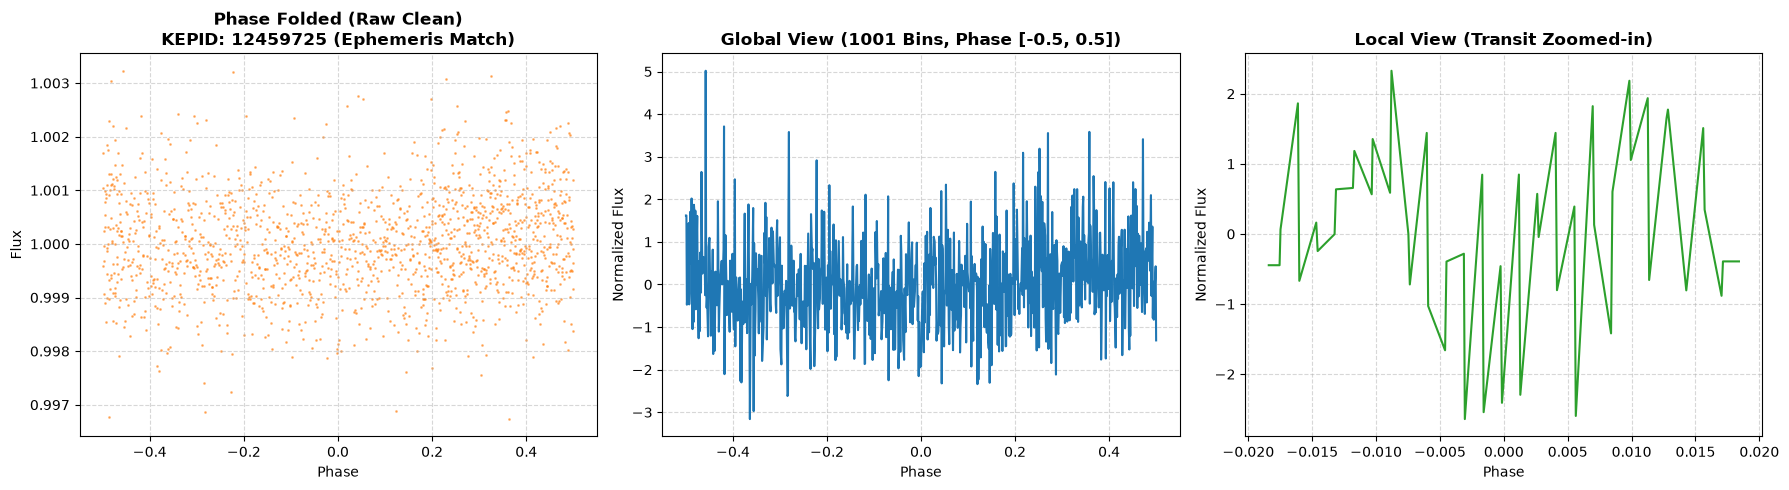

In [4]:
# Resolve dataset path
dataset_dir = "dataset"
if not os.path.exists(dataset_dir):
    dataset_dir = "model_2/dataset"

# Load Ephemeris Match data
eph_data_path = os.path.join(dataset_dir, f"{ephemeris_kepid}.npz")
data = np.load(eph_data_path)
time = data['time']
flux = data['flux']

period = float(ephemeris_row['koi_period'])
epoch = float(ephemeris_row['koi_time0bk'])
duration = float(ephemeris_row['koi_duration'])

# Remove outliers and fold
clean_time, clean_flux = remove_outliers(time, flux, sigma=5.0)
phases = phase_fold(clean_time, period, epoch)
global_view, local_view = preprocess_light_curve(time, flux, period, epoch, duration)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

# 1. Folded Raw/Clean light curve
axes[0].scatter(phases, clean_flux, s=1, color='#FF7F0E', alpha=0.5)
axes[0].set_title(f'Phase Folded (Raw Clean)\nKEPID: {ephemeris_kepid} (Ephemeris Match)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Phase')
axes[0].set_ylabel('Flux')
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Global View
axes[1].plot(np.linspace(-0.5, 0.5, 1001), global_view, color='#1F77B4', linewidth=1.5)
axes[1].set_title('Global View (1001 Bins, Phase [-0.5, 0.5])', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Phase')
axes[1].set_ylabel('Normalized Flux')
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Local View
duration_days = duration / 24.0
width = min(2.5 * (duration_days / period), 0.5)
axes[2].plot(np.linspace(-width, width, 1001), local_view, color='#2CA02C', linewidth=1.5)
axes[2].set_title('Local View (Transit Zoomed-in)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Phase')
axes[2].set_ylabel('Normalized Flux')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


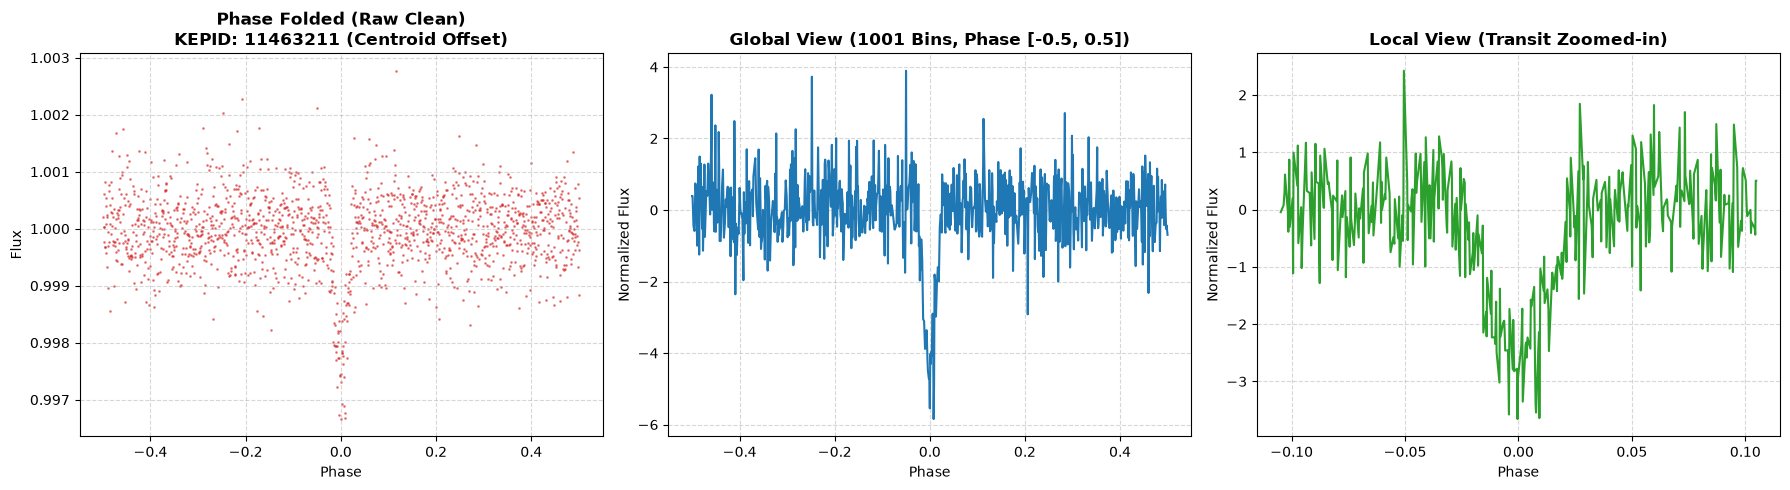

In [6]:
# Load Centroid Offset data
cent_data_path = os.path.join(dataset_dir, f"{centroid_kepid}.npz")
data = np.load(cent_data_path)
time = data['time']
flux = data['flux']

period = float(centroid_row['koi_period'])
epoch = float(centroid_row['koi_time0bk'])
duration = float(centroid_row['koi_duration'])

# Remove outliers and fold
clean_time, clean_flux = remove_outliers(time, flux, sigma=5.0)
phases = phase_fold(clean_time, period, epoch)
global_view, local_view = preprocess_light_curve(time, flux, period, epoch, duration)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

# 1. Folded Raw/Clean light curve
axes[0].scatter(phases, clean_flux, s=1, color='#D62728', alpha=0.5)
axes[0].set_title(f'Phase Folded (Raw Clean)\nKEPID: {centroid_kepid} (Centroid Offset)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Phase')
axes[0].set_ylabel('Flux')
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Global View
axes[1].plot(np.linspace(-0.5, 0.5, 1001), global_view, color='#1F77B4', linewidth=1.5)
axes[1].set_title('Global View (1001 Bins, Phase [-0.5, 0.5])', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Phase')
axes[1].set_ylabel('Normalized Flux')
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Local View
duration_days = duration / 24.0
width = min(2.5 * (duration_days / period), 0.5)
axes[2].plot(np.linspace(-width, width, 1001), local_view, color='#2CA02C', linewidth=1.5)
axes[2].set_title('Local View (Transit Zoomed-in)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Phase')
axes[2].set_ylabel('Normalized Flux')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
